# 02 — Feature engineering

Construye el dataset agregado por tiro a partir de `BD_tiros.csv`, usando la misma lógica que `scripts/prepare_data.py` (se importa directamente para no duplicar código).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts.prepare_data import build_features, report

sns.set_theme(style='whitegrid')

In [2]:
df_raw = pd.read_csv('../data/db/BD_tiros.csv')
features = build_features(df_raw)
report(features)
features.head()

  DATASET AGREGADO POR TIRO
  Tiros totales:        411
  Features generadas:   57
  Fallos (0):           66.2%
  Cestas (1):           33.8%
  Valores faltantes:    0


,tiro,session,n_muestras,duracion_ms,cesta,x_max,x_min,x_mean,x_std,x_range,...,potencia_kurtosis,potencia_idx_max_frac,potencia_first_half_mean,potencia_second_half_mean,potencia_asimetria_temporal,potencia_jerk_mean,potencia_jerk_std,x_sobre_potencia_mean,y_sobre_potencia_mean,z_sobre_potencia_mean
0,1,20260615_1F873475,17,9659.0,1,52.0,-84.0,-46.352941,26.535085,136.0,...,2.206131,0.250000,1017.362500,1015.454444,-1.908056,4.807500,7.074740,-0.045586,0.723932,-0.687806
1,2,20260615_1F873475,20,11521.0,0,-44.0,-120.0,-54.000000,15.466092,76.0,...,0.459617,0.315789,1019.551000,1013.626000,-5.925000,8.596842,10.574586,-0.053137,0.723017,-0.688565
2,3,20260615_1F873475,19,10890.0,1,-20.0,-52.0,-42.947368,6.723671,32.0,...,11.592143,0.055556,1021.074444,1008.014000,-13.060444,15.677778,31.411970,-0.042384,0.714500,-0.697835
3,4,20260620_0387810F,9,4949.0,0,2040.0,-1836.0,-246.666667,964.810171,3876.0,...,-0.096485,0.500000,806.872500,1713.730000,906.857500,629.325000,995.284020,-0.260479,-0.303878,-0.359066
4,5,20260620_0387810F,8,4230.0,0,2040.0,-1000.0,278.500000,1053.791132,3040.0,...,-0.876911,0.714286,1173.267500,1271.012500,97.745000,980.537143,1122.047167,0.146001,-0.349771,-0.340178


## Features generadas por tiro

Para cada eje (`x`, `y`, `z`, `potencia`) se calculan:
- `max`, `min`, `mean`, `std`, `range` (max-min)
- `skew`, `kurtosis` (forma de la distribución de muestras dentro del tiro)
- `idx_max_frac`: en qué fracción del tiro ocurre el pico (0=inicio, 1=final)
- `first_half_mean` / `second_half_mean` / `asimetria_temporal`: si el movimiento se concentra al inicio o al final del gesto
- `jerk_mean` / `jerk_std`: suavidad del movimiento (derivada entre muestras consecutivas)

Además: `n_muestras`, `duracion_ms` (por timestamp), y proxies de ángulo de lanzamiento (`{eje}_sobre_potencia_mean`, proporción de cada eje respecto a la potencia total).

In [3]:
features.to_csv('../data/processed/features_por_tiro.csv', index=False)
features.describe().T

,count,mean,std,min,25%,50%,75%,max
tiro,411.0,206.000000,118.789730,1.000000,103.500000,206.000000,308.500000,411.000000
n_muestras,411.0,8.800487,5.827111,5.000000,7.000000,7.000000,8.000000,52.000000
duracion_ms,411.0,4281.014599,3202.491439,2159.000000,3198.500000,3270.000000,3869.500000,27931.000000
cesta,411.0,0.338200,0.473673,0.000000,0.000000,0.000000,1.000000,1.000000
x_max,411.0,1109.167883,492.417073,-324.000000,748.000000,968.000000,1418.000000,2040.000000
x_min,411.0,-904.058394,571.839920,-2040.000000,-1248.000000,-768.000000,-502.000000,456.000000
x_mean,411.0,159.860964,303.181204,-1065.142857,25.000000,199.428571,366.955665,799.040000
x_std,411.0,613.679451,208.388296,6.723671,459.479280,587.467635,732.331893,1265.589288
x_range,411.0,2013.226277,729.529280,32.000000,1476.000000,1916.000000,2512.000000,4080.000000
x_skew,411.0,-0.239946,0.954055,-3.843125,-0.923741,-0.380222,0.346523,3.025472


## Correlación de features con el target (`cesta`)

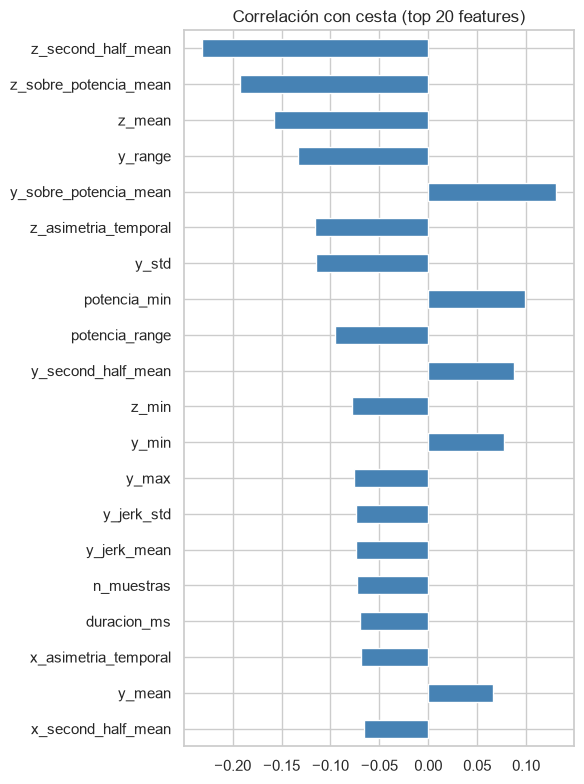

z_second_half_mean      -0.231405
z_sobre_potencia_mean   -0.192125
z_mean                  -0.157380
y_range                 -0.132925
y_sobre_potencia_mean    0.130824
z_asimetria_temporal    -0.115603
y_std                   -0.114935
potencia_min             0.098730
potencia_range          -0.095750
y_second_half_mean       0.087908
Name: cesta, dtype: float64

In [4]:
corr_target = (
    features.drop(columns=['tiro','session']).corr(numeric_only=True)['cesta']
    .drop('cesta').sort_values(key=abs, ascending=False)
)
fig, ax = plt.subplots(figsize=(6,8))
corr_target.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Correlación con cesta (top 20 features)')
plt.tight_layout()
plt.show()
corr_target.head(10)

**Observación:** las correlaciones lineales son débiles (|r| máximo ~0.2-0.25, en `z_second_half_mean` y `z_sobre_potencia_mean`). Esto anticipa que el techo de rendimiento de modelos lineales/basados en árboles con estas features agregadas será moderado — se confirma y cuantifica en los notebooks 03 y 04.

## Normalización de features

In [5]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in features.columns if c not in ('tiro','session','cesta')]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(features[feature_cols]), columns=feature_cols)
X_scaled.describe().T[['mean','std']].head()

,mean,std
n_muestras,0.000000e+00,1.001219
duracion_ms,1.728814e-17,1.001219
x_max,3.457629e-17,1.001219
x_min,3.025425e-17,1.001219
x_mean,-3.457629e-17,1.001219


## Manejo de clase desbalanceada

Dos estrategias evaluadas en `scripts/train_model.py` (flag `--imbalance`):
- `class_weight='balanced'` en cada estimador (por defecto).
- `SMOTE` (oversampling sintético) sobre el set de entrenamiento, vía `imbalanced-learn`.

El train/test split se hace estratificado (80/20) para preservar la proporción de clases en ambos conjuntos.

In [6]:
from sklearn.model_selection import train_test_split

X = features[feature_cols]
y = features['cesta']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, y_train.value_counts(normalize=True).to_dict())
print('Test: ', X_test.shape, y_test.value_counts(normalize=True).to_dict())

Train: (328, 57) {0: 0.6615853658536586, 1: 0.3384146341463415}
Test:  (83, 57) {0: 0.6626506024096386, 1: 0.3373493975903614}
